This notebook compute the symbolic distributions of $Y_n$. The recurrence is defined as

$$Y_{n} = I^{(n)}\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J^{(n)}\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_1=0.$$

Given that the subscripts are for iid copies. The variables $I^{(n)}$ and $J^{(n)}$ are Bernoulli with expectation $u$ and $v$ respectively such that $I^{(n)}+J^{(n)}\le 1$, and they are inpependent of all $Y^{(j)}_i$. The variable $U_n$ is uniform in $\{0,\ldots,n-1\}$. All the collections of iid copies are independent.

In [1]:
# Helper cell for folder setup and type checking. Only run if the kernel is Sage.
# sage -n jupyter --no-browser

import os, sys
print(os.getcwd(), sys.executable)

%cd /mnt/d/Projects/m2-bezout/internship/src/notebooks/
from utils import styled_print

from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from type_checking import *

/home/chocomint /home/chocomint/miniconda3/envs/sage/bin/python3
/mnt/d/Projects/m2-bezout/internship/src/notebooks


In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_exact_distributions_symbolic(max_N):
    # Declare u and v as symbolic variables
    u, v = var('u v')
    
    # Initialize matrices with Sage's Symbolic Ring (SR) zeros
    pmfs = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    cdfs = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    
    # Base cases: Y_0 = 0, Y_1 = 0
    pmfs[0][0] = SR(1)
    pmfs[1][0] = SR(1)
    
    for i in range(2):
        for k in range(max_N + 1):
            cdfs[i][k] = SR(1)

    termination_prob = 1 - u - v

    for n in range(2, max_N + 1):
        # Y_n is bounded by n - 1
        for k in range(n):
            prob_k = SR(0)
            
            # U_n is uniformly distributed over {0, ..., n-1}
            for i in range(n):
                idx1 = i
                idx2 = n - 1 - i
                
                # I: sum of independent copies + 1
                c_prob = SR(0)
                if k >= 1:
                    for j in range(k):
                        c_prob += pmfs[idx1][j] * pmfs[idx2][k - 1 - j]
                        
                # J: max of independent copies
                cdfs1_k = cdfs[idx1][k]
                cdfs2_k = cdfs[idx2][k]
                cdfs1_k_minus_1 = cdfs[idx1][k - 1] if k > 0 else SR(0)
                cdfs2_k_minus_1 = cdfs[idx2][k - 1] if k > 0 else SR(0)
                
                m_prob = (cdfs1_k * cdfs2_k) - (cdfs1_k_minus_1 * cdfs2_k_minus_1)
                
                prob_k += u * c_prob + v * m_prob
                
            t_prob = SR(1) if k == 0 else SR(0)
            
            # Divide by n for the uniform distribution expectation
            pmfs[n][k] = ((prob_k / n) + (termination_prob * t_prob)).expand()
            
        current_cdf = SR(0)
        for k in range(max_N + 1):
            if k < n:
                current_cdf += pmfs[n][k]
            cdfs[n][k] = current_cdf.expand()

    expected_values = []
    for i in range(1, max_N + 1):
        expected_y = sum(k * pmfs[i][k] for k in range(i))
        expected_values.append(expected_y.expand())

    return pmfs, cdfs, expected_values

In [3]:
pmfs, cdfs, evs = compute_exact_distributions_symbolic(20)

In [5]:
for i in range(10):
    styled_print(cdfs[i])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
len(str(cdfs[20]))

31163

In [9]:
def simulate_expectations_particles(max_N, num_particles, u, v):

    history = np.zeros((max_N + 1, num_particles), dtype=int)
    
    for n in range(2, max_N + 1):

        # Uniform indices
        Un = np.random.randint(0, n, size=num_particles)
        idx1 = Un
        idx2 = n - 1 - Un
        
        # Sample independent copies Y^(1) and Y^(2) 
        p_idx1 = np.random.randint(0, num_particles, size=num_particles)
        p_idx2 = np.random.randint(0, num_particles, size=num_particles)
        
        y1 = history[idx1, p_idx1]
        y2 = history[idx2, p_idx2]
        
        # Determine the Bernoulli events I and J
        rand_vals = np.random.rand(num_particles)
        
        mask_I = rand_vals < u
        mask_J = (rand_vals >= u) & (rand_vals < u + v)
        
        # Apply the recurrence formula conditionally
        y_new = np.zeros(num_particles, dtype=int)
        y_new[mask_I] = y1[mask_I] + y2[mask_I] + 1
        y_new[mask_J] = np.maximum(y1[mask_J], y2[mask_J])
        
        history[n] = y_new
        
    # Calculate the empirical expectation E[Y_n] across the particles
    expectations = np.mean(history, axis=1)
    
    return expectations, history

In [22]:
N = 5000

expectations, history = simulate_expectations_particles(N, 100000, u=0.6, v=0.2)
alpha_simulated = np.log(expectations[-1])/np.log(N)

print(alpha_simulated)

0.5245641933511656


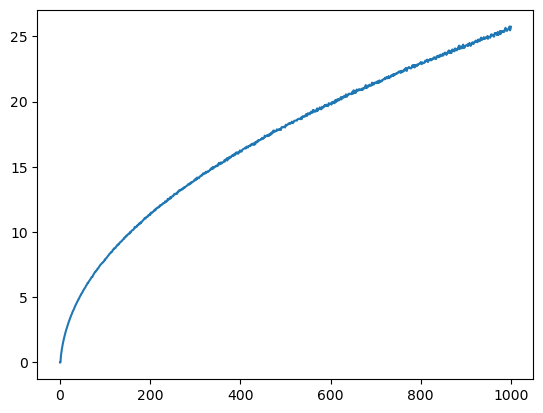

In [15]:
plt.plot(expectations, label='Empirical E[Y_n]')